# **MÓDULO 39 - Exercicio - Aplicando SVM**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros. A mesma que também usamos na tarefa de XGboost!


In [4]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [5]:
# 1. Carregar base de dados
df = pd.read_csv('CARRO_CLIENTES (1).csv')

# Visualizar primeiras linhas
print("=" * 50)
print(" PRIMEIRAS LINHAS")
print("=" * 50)
print(df.head())

# Tipos de dados
print("\n" + "=" * 50)
print(" TIPOS DE DADOS")
print("=" * 50)
print(df.dtypes)

# Dados faltantes
print("\n" + "=" * 50)
print(" DADOS FALTANTES")
print("=" * 50)
print(df.isnull().sum())

# Shape antes do drop
print(f"\nShape antes: {df.shape}")

# Drop coluna ID
df.drop(columns=['User ID'], inplace=True)

# Shape depois do drop
print(f"Shape depois: {df.shape}")
print(f"\nColunas restantes: {df.columns.tolist()}")


 PRIMEIRAS LINHAS
   User ID Gender  Age  AnnualSalary  Purchased
0      385   Male   35         20000          0
1      681   Male   40         43500          0
2      353   Male   49         74000          0
3      895   Male   40        107500          1
4      661   Male   25         79000          0

 TIPOS DE DADOS
User ID          int64
Gender          object
Age              int64
AnnualSalary     int64
Purchased        int64
dtype: object

 DADOS FALTANTES
User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

Shape antes: (1000, 5)
Shape depois: (1000, 4)

Colunas restantes: ['Gender', 'Age', 'AnnualSalary', 'Purchased']


# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [6]:
# Label Encoder para Gender
le = LabelEncoder()
df['Gender_enc'] = le.fit_transform(df['Gender'])

# Verificar mapeamento
print("Mapeamento:")
for classe, codigo in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {classe} -> {codigo}")

# Excluir coluna categorica original
df.drop(columns=['Gender'], inplace=True)

print(f"\nColunas atuais: {df.columns.tolist()}")
print(f"\n{df.head()}")


Mapeamento:
  Female -> 0
  Male -> 1

Colunas atuais: ['Age', 'AnnualSalary', 'Purchased', 'Gender_enc']

   Age  AnnualSalary  Purchased  Gender_enc
0   35         20000          0           1
1   40         43500          0           1
2   49         74000          0           1
3   40        107500          1           1
4   25         79000          0           1


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

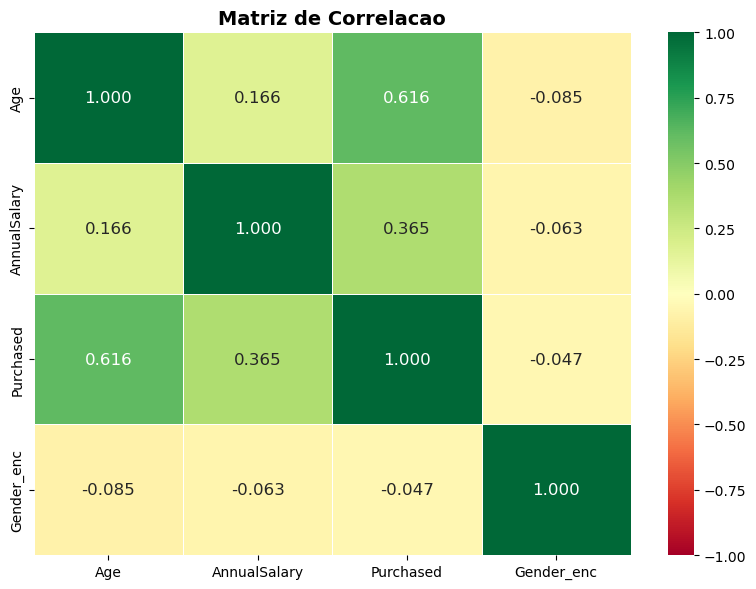

 CORRELACAO COM A TARGET (Purchased)
Age             0.616036
AnnualSalary    0.364974
Gender_enc     -0.047211


In [7]:
# Matriz de correlacao
corr = df.corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 12})
plt.title('Matriz de Correlacao', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlacao com a target
print("=" * 50)
print(" CORRELACAO COM A TARGET (Purchased)")
print("=" * 50)
corr_target = corr['Purchased'].drop('Purchased').sort_values(ascending=False)
print(corr_target.to_string())


# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [8]:
# Separacao X e Y
X = df.drop(columns=['Purchased'])
Y = df['Purchased']

print("=" * 50)
print(" DEFINICAO X e Y")
print("=" * 50)
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"\nFeatures: {X.columns.tolist()}")
print(f"\nDistribuicao Y:")
print(Y.value_counts())

# Separacao treino e teste (80/20 estratificado)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42, stratify=Y
)

print(f"\n{'=' * 50}")
print(f" TREINO / TESTE")
print(f"{'=' * 50}")
print(f"X_train: {X_train.shape}  |  Y_train: {Y_train.shape}")
print(f"X_test:  {X_test.shape}   |  Y_test:  {Y_test.shape}")
print(f"\nProporcao Y treino:\n{Y_train.value_counts(normalize=True).round(4) * 100}")
print(f"\nProporcao Y teste:\n{Y_test.value_counts(normalize=True).round(4) * 100}")


 DEFINICAO X e Y
X shape: (1000, 3)
Y shape: (1000,)

Features: ['Age', 'AnnualSalary', 'Gender_enc']

Distribuicao Y:
Purchased
0    598
1    402
Name: count, dtype: int64

 TREINO / TESTE
X_train: (800, 3)  |  Y_train: (800,)
X_test:  (200, 3)   |  Y_test:  (200,)

Proporcao Y treino:
Purchased
0    59.75
1    40.25
Name: proportion, dtype: float64

Proporcao Y teste:
Purchased
0    60.0
1    40.0
Name: proportion, dtype: float64


**Todos passos até aqui vocês realizaram na tarefa anterior também!**

# 5. Treino o modelo SVM com sua base de treino.
Esse modelo deve ser treinado usando o kernel linear.

In [9]:
# Padronizar os dados (essencial para SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Treino do modelo SVM com kernel linear
model_svm = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

model_svm.fit(X_train_scaled, Y_train)

print("=" * 50)
print(" MODELO SVM TREINADO")
print("=" * 50)
print(f"\n  Kernel: {model_svm.kernel}")
print(f"  Classes: {model_svm.classes_}")
print(f"  Vetores de suporte: {model_svm.n_support_}")
print(f"  Total vetores de suporte: {sum(model_svm.n_support_)}")


 MODELO SVM TREINADO

  Kernel: linear
  Classes: [0 1]
  Vetores de suporte: [170 169]
  Total vetores de suporte: 339


# 6. Realize as previsões para a base de teste e traga a avaliação.

 PREVISOES REALIZADAS
Total de previsoes: 200

Distribuicao das previsoes:
Nao comprou (0)    129
Comprou (1)         71
Name: count, dtype: int64

 ACCURACY
  0.8550 (85.50%)

 CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Nao comprou (0)       0.85      0.92      0.88       120
    Comprou (1)       0.86      0.76      0.81        80

       accuracy                           0.85       200
      macro avg       0.86      0.84      0.85       200
   weighted avg       0.86      0.85      0.85       200

 MATRIZ DE CONFUSAO


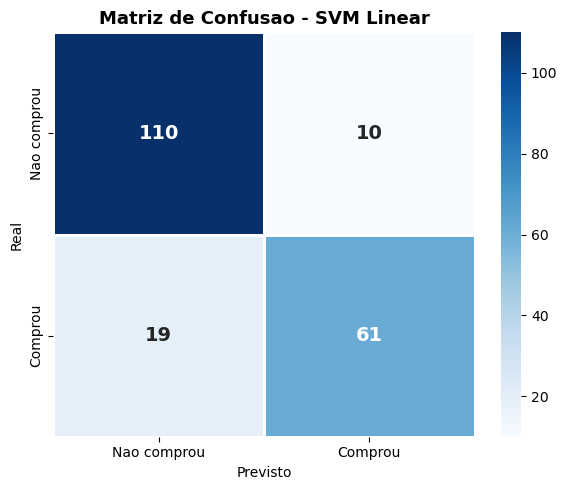


  Verdadeiros Negativos (VN): 110
  Falsos Positivos (FP):     10
  Falsos Negativos (FN):     19
  Verdadeiros Positivos (VP): 61


In [10]:
# 6. Previsoes e avaliacao
y_pred_svm = model_svm.predict(X_test_scaled)
y_proba_svm = model_svm.predict_proba(X_test_scaled)

print("=" * 50)
print(" PREVISOES REALIZADAS")
print("=" * 50)
print(f"Total de previsoes: {len(y_pred_svm)}")
print(f"\nDistribuicao das previsoes:")
print(pd.Series(y_pred_svm).value_counts().rename({0: 'Nao comprou (0)', 1: 'Comprou (1)'}))

print(f"\n{'=' * 50}")
print(f" ACCURACY")
print(f"{'=' * 50}")
acc = accuracy_score(Y_test, y_pred_svm)
print(f"  {acc:.4f} ({acc*100:.2f}%)")

print(f"\n{'=' * 50}")
print(f" CLASSIFICATION REPORT")
print(f"{'=' * 50}")
print(classification_report(Y_test, y_pred_svm,
      target_names=['Nao comprou (0)', 'Comprou (1)']))

print(f"{'=' * 50}")
print(f" MATRIZ DE CONFUSAO")
print(f"{'=' * 50}")
cm = confusion_matrix(Y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Nao comprou', 'Comprou'],
            yticklabels=['Nao comprou', 'Comprou'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Matriz de Confusao - SVM Linear', fontsize=13, fontweight='bold')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n  Verdadeiros Negativos (VN): {tn}")
print(f"  Falsos Positivos (FP):     {fp}")
print(f"  Falsos Negativos (FN):     {fn}")
print(f"  Verdadeiros Positivos (VP): {tp}")


# 7. Treine um novo modelo SVM com sua base de treino + realize as previsões e avalições.
Esse modelo dedve ser treinado usando o kernel poly.

 MODELO SVM POLY TREINADO

  Kernel: poly
  Grau: 3
  Vetores de suporte: [167 168]
  Total vetores de suporte: 335

 ACCURACY
  0.8750 (87.50%)

 CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Nao comprou (0)       0.86      0.95      0.90       120
    Comprou (1)       0.91      0.76      0.83        80

       accuracy                           0.88       200
      macro avg       0.88      0.86      0.87       200
   weighted avg       0.88      0.88      0.87       200

 MATRIZ DE CONFUSAO


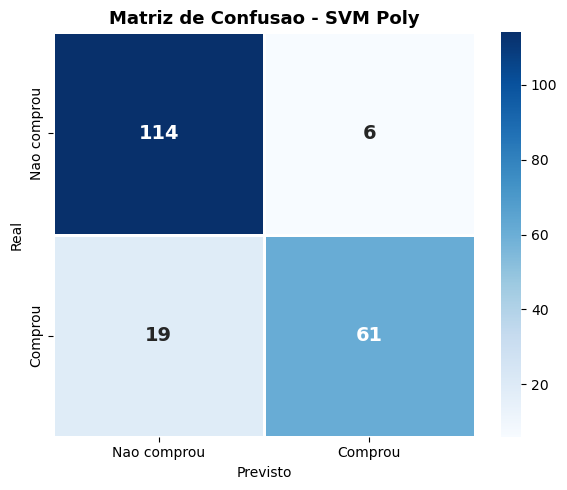


  Verdadeiros Negativos (VN): 114
  Falsos Positivos (FP):     6
  Falsos Negativos (FN):     19
  Verdadeiros Positivos (VP): 61


In [11]:
# 7. Treino do modelo SVM com kernel poly
model_svm_poly = SVC(
    kernel='poly',
    degree=3,            # grau do polinomio
    probability=True,
    random_state=42
)

model_svm_poly.fit(X_train_scaled, Y_train)

print("=" * 50)
print(" MODELO SVM POLY TREINADO")
print("=" * 50)
print(f"\n  Kernel: {model_svm_poly.kernel}")
print(f"  Grau: {model_svm_poly.degree}")
print(f"  Vetores de suporte: {model_svm_poly.n_support_}")
print(f"  Total vetores de suporte: {sum(model_svm_poly.n_support_)}")

# Previsoes
y_pred_poly = model_svm_poly.predict(X_test_scaled)

# Avaliacao
print(f"\n{'=' * 50}")
print(f" ACCURACY")
print(f"{'=' * 50}")
acc_poly = accuracy_score(Y_test, y_pred_poly)
print(f"  {acc_poly:.4f} ({acc_poly*100:.2f}%)")

print(f"\n{'=' * 50}")
print(f" CLASSIFICATION REPORT")
print(f"{'=' * 50}")
print(classification_report(Y_test, y_pred_poly,
      target_names=['Nao comprou (0)', 'Comprou (1)']))

print(f"{'=' * 50}")
print(f" MATRIZ DE CONFUSAO")
print(f"{'=' * 50}")
cm_poly = confusion_matrix(Y_test, y_pred_poly)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_poly, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Nao comprou', 'Comprou'],
            yticklabels=['Nao comprou', 'Comprou'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Matriz de Confusao - SVM Poly', fontsize=13, fontweight='bold')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_poly.ravel()
print(f"\n  Verdadeiros Negativos (VN): {tn}")
print(f"  Falsos Positivos (FP):     {fp}")
print(f"  Falsos Negativos (FN):     {fn}")
print(f"  Verdadeiros Positivos (VP): {tp}")


# 8. Qual modelo se saiu melhor? O SVM com kernel linear ou poly? Compare também com o XGboost, da atividade anterior, você obteve melhores previsões com qual dos modelos?

Entre os dois modelos SVM testados, o kernel polinomial apresentou desempenho superior ao linear. O SVM Poly alcançou Accuracy de 87.50% contra 85.50% do Linear, e também se destacou na Precision da classe "Comprou" (0.91 vs 0.86), o que significa que quando o modelo Poly diz que um cliente vai comprar, ele acerta com mais frequência. Isso faz sentido porque a relacao entre idade, salário e decisão de compra dificilmente é uma linha reta , o kernel polinomial consegue capturar essas curvaturas que o linear ignora.

Quando trazemos o XGBoost para a comparação, ele se mostrou o modelo mais robusto entre os três. Observamos isso ja na etapa de probabilidades, onde o XGBoost apresentava predições com confiança muito alta (acima de 0.90 na maioria dos casos), enquanto o SVM tende a ser mais conservador nas suas estimativas. O XGBoost lida naturalmente com relações não lineares e interações entre variáveis sem precisar de padronização, o que da vantagem sobre o SVM em dados tabulares deste tipo.

Em resumo, o ranking final é: XGBoost em primeiro, seguido pelo SVM Poly em segundo e SVM Linear em terceiro. Para um problema como este, de classificação binária com poucas features e dados tabulares, o XGBoost continua sendo a escolha mais indicada, mas o SVM Poly se mostrou uma alternativa competitiva, especialmente quando ha necessidade de um modelo mais simples e interpretavel.
